In [1]:
from pathlib import Path

# Notebook is in: Scripts/
PROJECT_ROOT = Path.cwd().parent
VIDEO_DIR = PROJECT_ROOT / "Data" / "videos_160"
GOLFDB_DIR = PROJECT_ROOT / "golfdb"

print("Project root:", PROJECT_ROOT)
print("Video dir exists:", VIDEO_DIR.exists())
print("GolfDB dir exists:", GOLFDB_DIR.exists())

video_files = sorted(
    list(VIDEO_DIR.glob("*.mp4"))
)

print(f"Found {len(video_files)} videos")
video_files[:5]

Project root: c:\Users\theod\DS210\SinglePOVGolfSwingReconstructionUsingSimulatedBiomechanicalAI
Video dir exists: True
GolfDB dir exists: True
Found 1400 videos


[WindowsPath('c:/Users/theod/DS210/SinglePOVGolfSwingReconstructionUsingSimulatedBiomechanicalAI/Data/videos_160/0.mp4'),
 WindowsPath('c:/Users/theod/DS210/SinglePOVGolfSwingReconstructionUsingSimulatedBiomechanicalAI/Data/videos_160/1.mp4'),
 WindowsPath('c:/Users/theod/DS210/SinglePOVGolfSwingReconstructionUsingSimulatedBiomechanicalAI/Data/videos_160/10.mp4'),
 WindowsPath('c:/Users/theod/DS210/SinglePOVGolfSwingReconstructionUsingSimulatedBiomechanicalAI/Data/videos_160/100.mp4'),
 WindowsPath('c:/Users/theod/DS210/SinglePOVGolfSwingReconstructionUsingSimulatedBiomechanicalAI/Data/videos_160/1000.mp4')]

In [2]:
from IPython.display import Video, display

sample_video = video_files[0]
print(sample_video)

display(Video(str(sample_video), embed=True, width=320))

c:\Users\theod\DS210\SinglePOVGolfSwingReconstructionUsingSimulatedBiomechanicalAI\Data\videos_160\0.mp4


In [3]:
import cv2

def get_video_info(video_path):
    cap = cv2.VideoCapture(str(video_path))
    
    if not cap.isOpened():
        raise ValueError(f"Could not open video: {video_path}")
    
    info = {
        "path": str(video_path),
        "frame_count": int(cap.get(cv2.CAP_PROP_FRAME_COUNT)),
        "fps": cap.get(cv2.CAP_PROP_FPS),
        "width": int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)),
        "height": int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)),
    }
    
    info["duration_seconds"] = info["frame_count"] / info["fps"] if info["fps"] else None
    
    cap.release()
    return info

get_video_info(sample_video)

{'path': 'c:\\Users\\theod\\DS210\\SinglePOVGolfSwingReconstructionUsingSimulatedBiomechanicalAI\\Data\\videos_160\\0.mp4',
 'frame_count': 138,
 'fps': 29.978,
 'width': 160,
 'height': 160,
 'duration_seconds': 4.603375808926546}

In [4]:
import cv2
import matplotlib.pyplot as plt

def load_video_frames(video_path, max_frames=None, rgb=True):
    cap = cv2.VideoCapture(str(video_path))
    
    if not cap.isOpened():
        raise ValueError(f"Could not open video: {video_path}")
    
    frames = []
    count = 0
    
    while True:
        ret, frame = cap.read()
        
        if not ret:
            break
        
        if rgb:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        
        frames.append(frame)
        count += 1
        
        if max_frames is not None and count >= max_frames:
            break
    
    cap.release()
    return frames

frames = load_video_frames(sample_video, max_frames=10)

print(f"Loaded {len(frames)} frames")
print("Frame shape:", frames[0].shape)

Loaded 10 frames
Frame shape: (160, 160, 3)


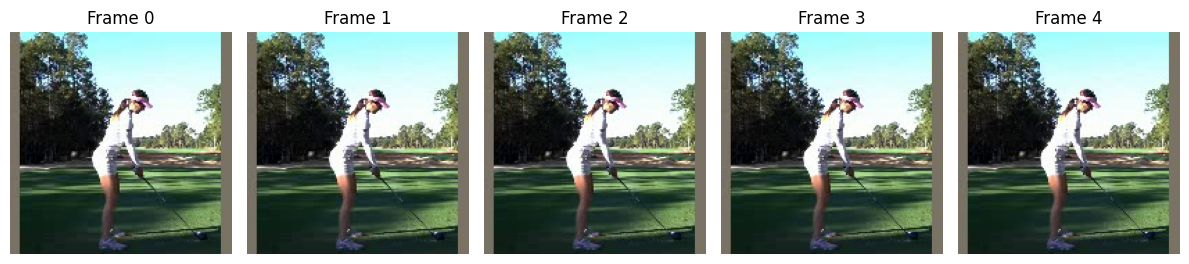

In [5]:
plt.figure(figsize=(12, 4))

for i, frame in enumerate(frames[:5]):
    plt.subplot(1, 5, i + 1)
    plt.imshow(frame)
    plt.title(f"Frame {i}")
    plt.axis("off")

plt.tight_layout()
plt.show()

***MEDIAPOSE***

In [6]:
import mediapipe as mp

print("MediaPipe object:", mp)
print("MediaPipe file:", getattr(mp, "__file__", "No __file__ found"))
print("MediaPipe version:", getattr(mp, "__version__", "No version found"))
print("Has solutions:", hasattr(mp, "solutions"))
print("Available attributes:", dir(mp)[:50])

MediaPipe object: <module 'mediapipe' from 'c:\\Users\\theod\\ANACONDA3\\envs\\GolfRender\\Lib\\site-packages\\mediapipe\\__init__.py'>
MediaPipe file: c:\Users\theod\ANACONDA3\envs\GolfRender\Lib\site-packages\mediapipe\__init__.py
MediaPipe version: 0.10.35
Has solutions: False
Available attributes: ['Image', 'ImageFormat', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', 'tasks']


In [7]:
import urllib.request
from pathlib import Path

MODEL_DIR = Path("../Models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

model_path = MODEL_DIR / "pose_landmarker_heavy.task"

url = "https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_heavy/float16/latest/pose_landmarker_heavy.task"

urllib.request.urlretrieve(url, model_path)

print("Downloaded:", model_path)

Downloaded: ..\Models\pose_landmarker_heavy.task


In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import pandas as pd
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

In [9]:
BaseOptions = mp.tasks.BaseOptions
PoseLandmarker = vision.PoseLandmarker
PoseLandmarkerOptions = vision.PoseLandmarkerOptions
VisionRunningMode = vision.RunningMode

options = PoseLandmarkerOptions(
    base_options=BaseOptions(model_asset_path=str(model_path)),
    running_mode=VisionRunningMode.IMAGE,
    num_poses=1,
    min_pose_detection_confidence=0.5,
    min_pose_presence_confidence=0.5,
    min_tracking_confidence=0.5,
)

landmarker = PoseLandmarker.create_from_options(options)

In [10]:
sample_video = video_files[0]
frames = load_video_frames(sample_video, max_frames=30)

frame = frames[10]

# Your load_video_frames function should already return RGB.
mp_image = mp.Image(
    image_format=mp.ImageFormat.SRGB,
    data=np.asarray(frame)
)

result = landmarker.detect(mp_image)

print("Number of poses detected:", len(result.pose_landmarks))

Number of poses detected: 1


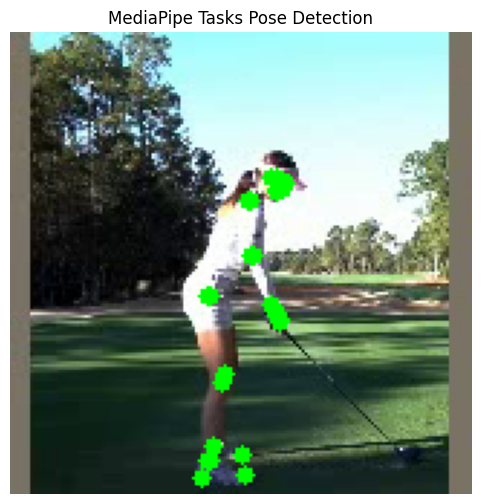

In [11]:
annotated_frame = frame.copy()

if result.pose_landmarks:
    h, w, _ = annotated_frame.shape
    landmarks = result.pose_landmarks[0]

    for lm in landmarks:
        x = int(lm.x * w)
        y = int(lm.y * h)
        cv2.circle(annotated_frame, (x, y), 3, (0, 255, 0), -1)

plt.figure(figsize=(6, 6))
plt.imshow(annotated_frame)
plt.axis("off")
plt.title("MediaPipe Tasks Pose Detection")
plt.show()

In [12]:
BaseOptions = mp.tasks.BaseOptions
PoseLandmarker = vision.PoseLandmarker
PoseLandmarkerOptions = vision.PoseLandmarkerOptions
VisionRunningMode = vision.RunningMode

options = PoseLandmarkerOptions(
    base_options=BaseOptions(model_asset_path=str(model_path)),
    running_mode=VisionRunningMode.VIDEO,
    num_poses=1,
    min_pose_detection_confidence=0.5,
    min_pose_presence_confidence=0.5,
    min_tracking_confidence=0.5,
)

In [13]:
POSE_LANDMARK_NAMES = [
    "NOSE",
    "LEFT_EYE_INNER",
    "LEFT_EYE",
    "LEFT_EYE_OUTER",
    "RIGHT_EYE_INNER",
    "RIGHT_EYE",
    "RIGHT_EYE_OUTER",
    "LEFT_EAR",
    "RIGHT_EAR",
    "MOUTH_LEFT",
    "MOUTH_RIGHT",
    "LEFT_SHOULDER",
    "RIGHT_SHOULDER",
    "LEFT_ELBOW",
    "RIGHT_ELBOW",
    "LEFT_WRIST",
    "RIGHT_WRIST",
    "LEFT_PINKY",
    "RIGHT_PINKY",
    "LEFT_INDEX",
    "RIGHT_INDEX",
    "LEFT_THUMB",
    "RIGHT_THUMB",
    "LEFT_HIP",
    "RIGHT_HIP",
    "LEFT_KNEE",
    "RIGHT_KNEE",
    "LEFT_ANKLE",
    "RIGHT_ANKLE",
    "LEFT_HEEL",
    "RIGHT_HEEL",
    "LEFT_FOOT_INDEX",
    "RIGHT_FOOT_INDEX",
]

POSE_CONNECTIONS = [
    (0, 1), (1, 2), (2, 3), (3, 7),
    (0, 4), (4, 5), (5, 6), (6, 8),
    (9, 10),
    (11, 12),
    (11, 13), (13, 15),
    (12, 14), (14, 16),
    (11, 23), (12, 24),
    (23, 24),
    (23, 25), (25, 27),
    (24, 26), (26, 28),
    (27, 29), (29, 31),
    (28, 30), (30, 32),
    (27, 31),
    (28, 32),
]

In [14]:
def draw_pose_landmarks_tasks_api(frame_rgb, pose_landmarks):
    """
    Draws MediaPipe Tasks API pose landmarks on an RGB frame.
    Returns an RGB annotated frame.
    """
    annotated = frame_rgb.copy()
    h, w, _ = annotated.shape

    # Draw connections
    for start_idx, end_idx in POSE_CONNECTIONS:
        if start_idx < len(pose_landmarks) and end_idx < len(pose_landmarks):
            start = pose_landmarks[start_idx]
            end = pose_landmarks[end_idx]

            x1, y1 = int(start.x * w), int(start.y * h)
            x2, y2 = int(end.x * w), int(end.y * h)

            cv2.line(annotated, (x1, y1), (x2, y2), (255, 255, 255), 2)

    # Draw joints
    for lm in pose_landmarks:
        x, y = int(lm.x * w), int(lm.y * h)
        cv2.circle(annotated, (x, y), 3, (0, 255, 0), -1)

    return annotated

In [15]:
def process_video_with_mediapipe_tasks(
    input_video_path,
    output_video_path,
    output_csv_path,
    model_path,
    max_frames=None,
    draw_overlay=True,
):
    input_video_path = Path(input_video_path)
    output_video_path = Path(output_video_path)
    output_csv_path = Path(output_csv_path)

    output_video_path.parent.mkdir(parents=True, exist_ok=True)
    output_csv_path.parent.mkdir(parents=True, exist_ok=True)

    cap = cv2.VideoCapture(str(input_video_path))

    if not cap.isOpened():
        raise ValueError(f"Could not open video: {input_video_path}")

    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    print("Input video:", input_video_path.name)
    print("FPS:", fps)
    print("Width:", width)
    print("Height:", height)
    print("Total frames:", total_frames)

    writer = None

    if draw_overlay:
        fourcc = cv2.VideoWriter_fourcc(*"mp4v")
        writer = cv2.VideoWriter(
            str(output_video_path),
            fourcc,
            fps,
            (width, height)
        )

    options = PoseLandmarkerOptions(
        base_options=BaseOptions(model_asset_path=str(model_path)),
        running_mode=VisionRunningMode.VIDEO,
        num_poses=1,
        min_pose_detection_confidence=0.5,
        min_pose_presence_confidence=0.5,
        min_tracking_confidence=0.5,
    )

    rows = []
    frame_idx = 0

    with PoseLandmarker.create_from_options(options) as landmarker:
        while True:
            ret, frame_bgr = cap.read()

            if not ret:
                break

            frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)

            mp_image = mp.Image(
                image_format=mp.ImageFormat.SRGB,
                data=np.ascontiguousarray(frame_rgb)
            )

            # MediaPipe VIDEO mode requires timestamp in milliseconds.
            timestamp_ms = int((frame_idx / fps) * 1000)

            result = landmarker.detect_for_video(mp_image, timestamp_ms)

            if result.pose_landmarks:
                pose_landmarks = result.pose_landmarks[0]

                for landmark_id, lm in enumerate(pose_landmarks):
                    rows.append({
                        "video": input_video_path.name,
                        "frame": frame_idx,
                        "timestamp_ms": timestamp_ms,
                        "landmark_id": landmark_id,
                        "landmark_name": POSE_LANDMARK_NAMES[landmark_id],
                        "x": lm.x,
                        "y": lm.y,
                        "z": lm.z,
                        "visibility": lm.visibility,
                        "presence": lm.presence,
                    })

                if draw_overlay:
                    annotated_rgb = draw_pose_landmarks_tasks_api(
                        frame_rgb,
                        pose_landmarks
                    )
                    annotated_bgr = cv2.cvtColor(annotated_rgb, cv2.COLOR_RGB2BGR)
                    writer.write(annotated_bgr)

            else:
                if draw_overlay:
                    writer.write(frame_bgr)

            frame_idx += 1

            if frame_idx % 50 == 0:
                print(f"Processed {frame_idx} frames...")

            if max_frames is not None and frame_idx >= max_frames:
                break

    cap.release()

    if writer is not None:
        writer.release()

    pose_df = pd.DataFrame(rows)
    pose_df.to_csv(output_csv_path, index=False)

    print("Done.")
    print("Frames processed:", frame_idx)
    print("Pose rows:", len(pose_df))
    print("Saved CSV:", output_csv_path)

    if draw_overlay:
        print("Saved overlay video:", output_video_path)

    return pose_df

In [18]:
OUTPUT_DIR = PROJECT_ROOT / "Data" / "pose_outputs"
CSV_DIR = PROJECT_ROOT / "Data" / "pose_landmarks"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CSV_DIR.mkdir(parents=True, exist_ok=True)

sample_video = video_files[0]

output_video = OUTPUT_DIR / f"{sample_video.stem}_tasks_pose_overlay.mp4"
output_csv = CSV_DIR / f"{sample_video.stem}_tasks_pose_landmarks.csv"

pose_df = process_video_with_mediapipe_tasks(
    input_video_path=sample_video,
    output_video_path=output_video,
    output_csv_path=output_csv,
    model_path=model_path,
    max_frames=None,
    draw_overlay=True,
)

pose_df.head()

Input video: 0.mp4
FPS: 29.978
Width: 160
Height: 160
Total frames: 138
Processed 50 frames...
Processed 100 frames...
Done.
Frames processed: 138
Pose rows: 4554
Saved CSV: c:\Users\theod\DS210\SinglePOVGolfSwingReconstructionUsingSimulatedBiomechanicalAI\Data\pose_landmarks\0_tasks_pose_landmarks.csv
Saved overlay video: c:\Users\theod\DS210\SinglePOVGolfSwingReconstructionUsingSimulatedBiomechanicalAI\Data\pose_outputs\0_tasks_pose_overlay.mp4


,video,frame,timestamp_ms,landmark_id,landmark_name,x,y,z,visibility,presence
0,0.mp4,0,0,0,NOSE,0.597106,0.342706,-0.031919,0.999953,0.999996
1,0.mp4,0,0,1,LEFT_EYE_INNER,0.599299,0.328902,-0.013720,0.999908,0.999993
2,0.mp4,0,0,2,LEFT_EYE,0.598269,0.327167,-0.014001,0.999898,0.999994
3,0.mp4,0,0,3,LEFT_EYE_OUTER,0.597410,0.325426,-0.013876,0.999918,0.999992
4,0.mp4,0,0,4,RIGHT_EYE_INNER,0.596814,0.327783,-0.066006,0.999950,0.999993


In [19]:
display(Video(str(output_video), embed=True, width=320))

In [20]:
h264_output_video = OUTPUT_DIR / f"{sample_video.stem}_tasks_pose_overlay_h264.mp4"

!ffmpeg -y -i "{output_video}" -vcodec libx264 -pix_fmt yuv420p "{h264_output_video}"

ffmpeg version 8.1.1 Copyright (c) 2000-2026 the FFmpeg developers
  built with clang version 22.1.4
  configuration: --prefix=/d/bld/ffmpeg_1777899916390/_h_env/Library --cc=clang.exe --cxx=clang++.exe --nm=llvm-nm --ar=llvm-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libopenh264 --enable-libdav1d --ld=lld-link --target-os=win64 --enable-cross-compile --toolchain=msvc --host-cc=clang.exe --extra-libs=ucrt.lib --extra-libs=vcruntime.lib --extra-libs=oldnames.lib --strip=llvm-strip --disable-stripping --host-extralibs= --disable-libopenvino --enable-gpl --enable-libx264 --enable-libx265 --enable-libmp3lame --enable-libaom --enable-libsvtav1 --enable-libxml2 --enable-pic --enable-shared --disable-static --enable-version3 --enable-zlib --enable-libvorbis --enable-libopus --enable-librsvg --enable-libjxl --enable-libwebp --enable-ffplay --enable-vulkan --enable-libshaderc --pkg-c

In [21]:
display(Video(str(h264_output_video), embed=True, width=320))

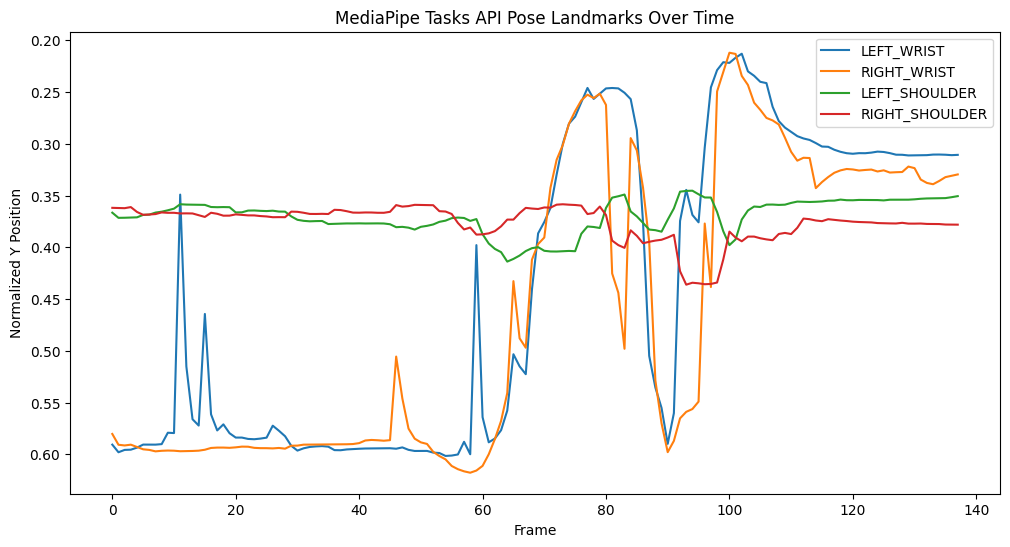

In [22]:
plt.figure(figsize=(12, 6))

for landmark in ["LEFT_WRIST", "RIGHT_WRIST", "LEFT_SHOULDER", "RIGHT_SHOULDER"]:
    temp = pose_df[pose_df["landmark_name"] == landmark]
    plt.plot(temp["frame"], temp["y"], label=landmark)

plt.gca().invert_yaxis()
plt.xlabel("Frame")
plt.ylabel("Normalized Y Position")
plt.title("MediaPipe Tasks API Pose Landmarks Over Time")
plt.legend()
plt.show()